# EN3160 Assignment 01

## Student Details

- **Name:** KPCP Keerawella
- **Index Number:** 230332B
- **GitHub Profile:** chalee88

## Introduction

This notebook contains the solutions for Assignment 01 on intensity transformations and neighborhood filtering.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

---

## Question 01 - Piecewise Linear Intensity Transformation

### Objective

- Implement `intensity_transform(im, breakpoints)`.
- Apply the transformation to the image in Fig. 1b.
- Show the transformation plot and original/transformed images side-by-side.

### Discussion

- Explain the selected breakpoints and their effect on the output image.

In [2]:
def intensity_transform(im, breakpoints):
    """
    Apply a piecewise linear intensity transformation to a grayscale image. 

    Parameters
    ----------
    im : np.ndarray
        Input grascale image with intensity values in [0, 255]

    breakpoints : np.ndarray
        Array of shape (N, 2) where each row is:
        [input_intensity, output_intensity]

    Returns 
    -------
    transformed : np.ndarray
        Transformed grayscale image.

    transform : np.ndarray
        Lookup table containing the output value for each input
        intesity from 0 to 255.
    """


    # Input and output coordinates of the breakpoints
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    # All possible input intensity values
    input_levels = np.arange(256)

    # Piecewise-linear interpolation between the breakpoints
    transform = np.interp(input_levels, x, y)

    # Make sure output intensities stay inside (0, 255)
    transform = np.clip(transform, 0, 255).astype(np.uint8)

    # Apply the lookup table to every pixel
    transformed = cv.LUT(im, transform)

    return transformed, transform


In [3]:
# load the image

im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

# breakpoints given in the assignment 

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

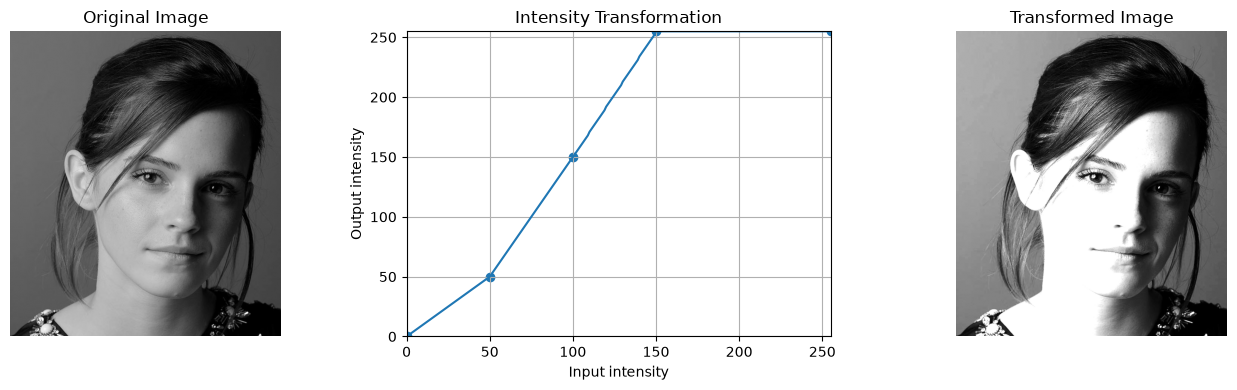

In [4]:
# apply transformation

im_transformed, transform = intensity_transform(im, breakpoints)    

# display results
plt.figure(figsize=(14, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

# Transformation 
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity") 
plt.title("Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

# Transformed image
plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()


In [22]:
breakpoints = np.array([
    [0, 0],
    [50, 100],
    [100, 130],
    [150, 180],
    [255, 255]
], dtype=np.float32)

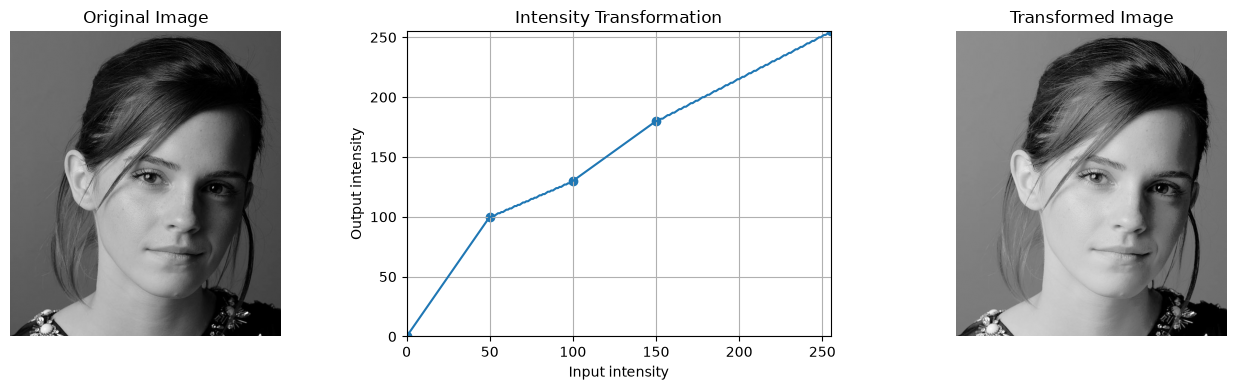

In [23]:
# apply transformation

im_transformed, transform = intensity_transform(im, breakpoints)    

# display results
plt.figure(figsize=(14, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

# Transformation 
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity") 
plt.title("Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

# Transformed image
plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
breakpoints = np.array([
    [0, 0],
    [50, 70],
    [100, 125],
    [150, 180],
    [255, 255]
], dtype=np.float32)

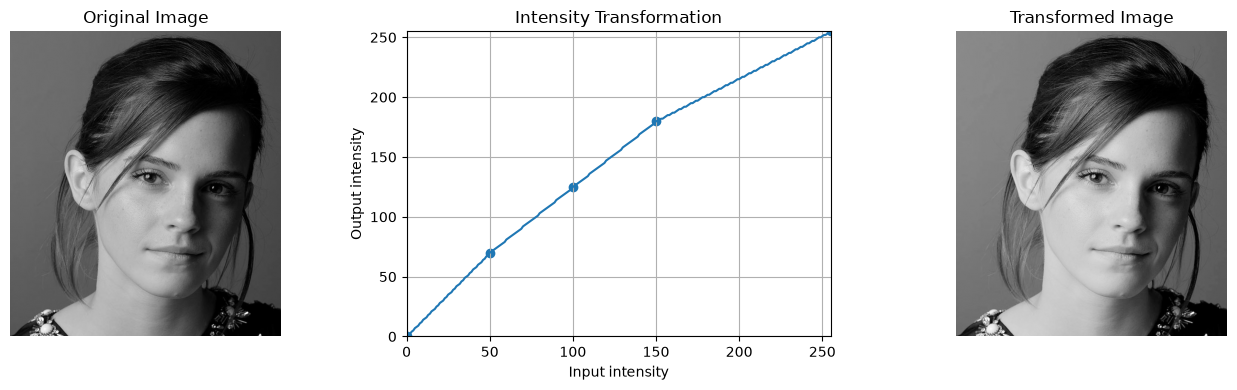

In [27]:
# apply transformation

im_transformed, transform = intensity_transform(im, breakpoints)    

# display results
plt.figure(figsize=(14, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

# Transformation 
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), transform)
plt.scatter(
    breakpoints[:, 0],
    breakpoints[:, 1],
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity") 
plt.title("Intensity Transformation")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid()

# Transformed image
plt.subplot(1, 3, 3)
plt.imshow(im_transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

The initial given breakpoints caused intensities above 150 to map to 255, which resulted in substantial highlight saturation and loss of detail. The breakpoints were therefore adjusted to provide moderate expansion of the shadow and midtone ranges while compressing the higher intensity range. This preserved highlight information while improving the visibility of darker details. 

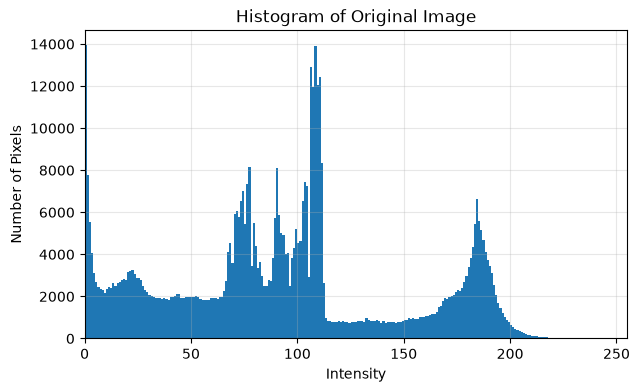

In [28]:
plt.figure(figsize=(7, 4))
plt.hist(im.ravel(), bins=256, range=[0, 256])
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Original Image")
plt.xlim([0, 255])
plt.grid(alpha=0.3)
plt.show()

---

## Question 02 - Brain Proton Density Image Enhancement

### Objective

- Apply intensity transformations to accentuate white matter and gray matter separately.
- Show the transformation plots.

### Sections

- White matter enhancement
- Gray matter enhancement
- Comparison and interpretation

In [ ]:
# Question 02 code

---

## Question 03 - Gamma Correction in L*a*b* Color Space

### Objective

- Apply gamma correction to the `L` plane in `L*a*b*` color space.
- State the selected gamma value.
- Show histograms of original and corrected images.

### Gamma Value

- `gamma = `

In [ ]:
# Question 03 code

---

## Question 04 - Vibrance Enhancement Using Saturation Transformation

### Objective

- Split the image into hue, saturation, and value planes.
- Apply the vibrance transformation to the saturation plane.
- Adjust `a` and report the selected value.
- Display the original image, enhanced image, and transformation.

### Parameters

- `sigma = 70`
- `a = `

In [ ]:
# Question 04 code

---

## Question 05 - Histogram Equalization From Scratch

### Objective

- Write a custom histogram equalization function.
- Apply it to the image in Fig. 5.
- Show histograms before and after equalization.

### Discussion

- Explain how the histogram and contrast changed after equalization.

In [ ]:
# Question 05 code

---

## Question 06 - Foreground-Only Histogram Equalization

### Objective

- Split the image into HSV planes and display them in grayscale.
- Extract a foreground mask by thresholding a suitable plane.
- Histogram-equalize only the foreground.
- Recombine the equalized foreground with the background.

### Results To Show

- Hue, saturation, and value planes
- Foreground mask
- Original image
- Image with histogram-equalized foreground

In [ ]:
# Question 06 code

---

## Question 07 - Sobel Filtering

### Objective

- Apply Sobel filtering using `cv.filter2D`.
- Write a custom Sobel filtering implementation.
- Use the separable property of the Sobel operator.

### Comparison

- Compare the three Sobel filtering outputs and discuss efficiency.

In [ ]:
# Question 07 code

---

## Question 08 - Image Zooming

### Objective

- Write a zoom function for scale factor `s` in `(0, 10]`.
- Support nearest-neighbor interpolation.
- Support bilinear interpolation.
- Test by scaling small images by a factor of 4.
- Compare with original large images using normalized SSD.

### Results To Show

- Nearest-neighbor zoomed images
- Bilinear zoomed images
- Normalized SSD values

In [ ]:
# Question 08 code

---

## Question 09 - Foreground Segmentation and Background Blur

### Objective

- Use grabCut to segment the flower image.
- Show the final segmentation mask, foreground image, and background image.
- Produce an enhanced image with a substantially blurred background.
- Explain why the background near the flower edge appears dark.

### Results To Show

- Segmentation mask
- Foreground image
- Background image
- Original and enhanced images side-by-side

In [ ]:
# Question 09 code

---

## Question 10 - Bilateral Filtering

### Objective

- Smooth the Lake Minaret image while keeping edges sharp.
- Apply OpenCV's `bilateralFilter`.
- Implement a custom bilateral filter.
- Compare Gaussian blur, OpenCV bilateral filtering, and custom bilateral filtering.
- Use a quantitative measure to compare the results.

### Parameters

- `sigma_s = `
- `sigma_r = `
- Gaussian kernel size: 
- Quantitative metric: 

In [ ]:
# Question 10 code

---

## Conclusion

- Summarize the main observations from all questions.
- Compare the effectiveness of different enhancement and filtering techniques.
- Mention limitations and possible improvements.

## References

- Assignment PDF
- Lecture slides
- OpenCV documentation
- NumPy documentation